First 5 Rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Numerical Columns:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'park

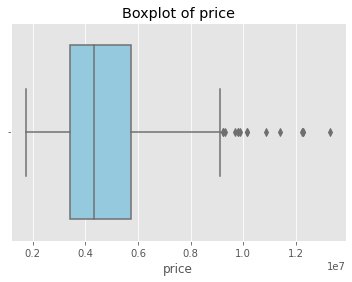

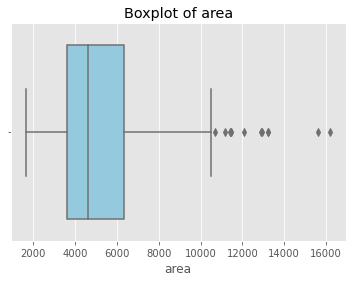

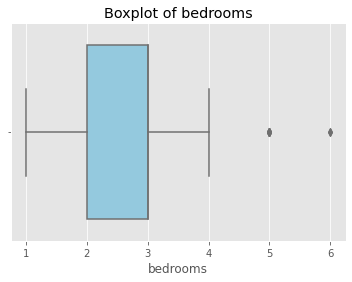

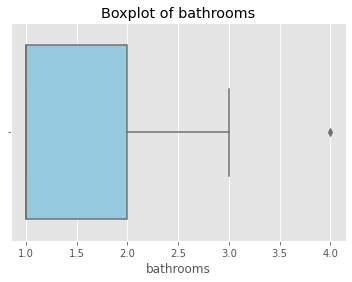

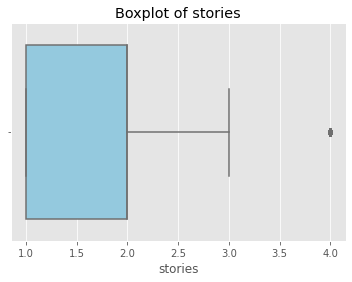

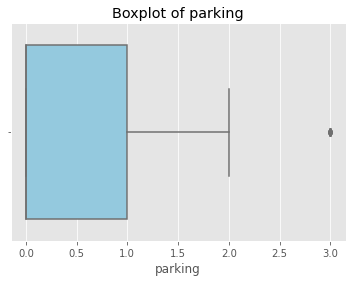

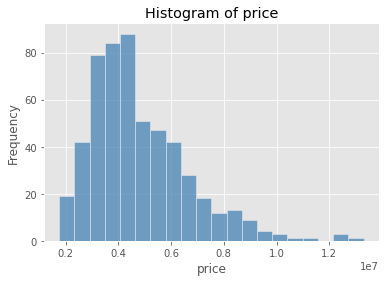

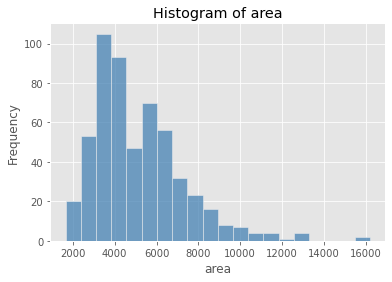

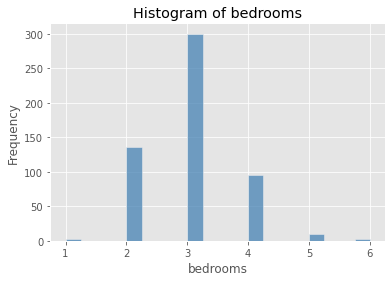

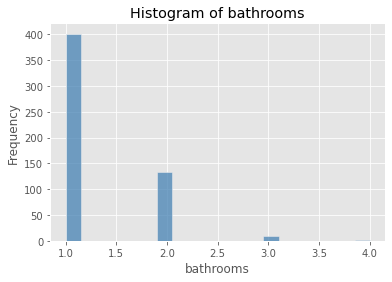

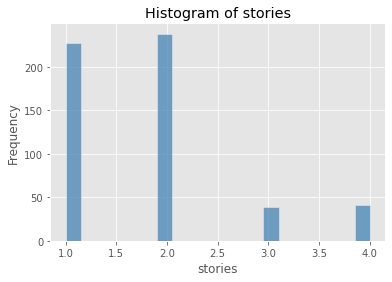

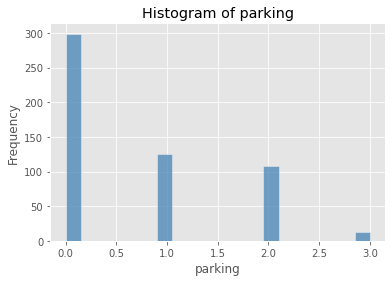

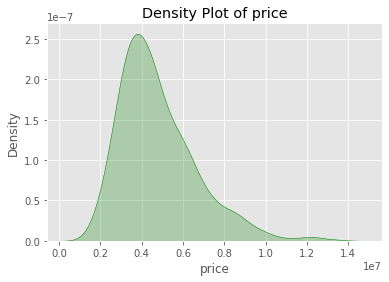

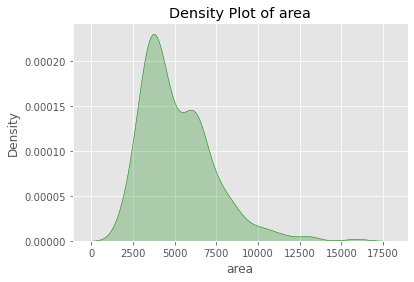

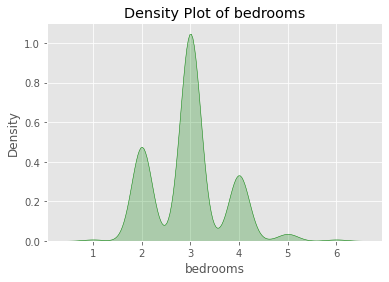

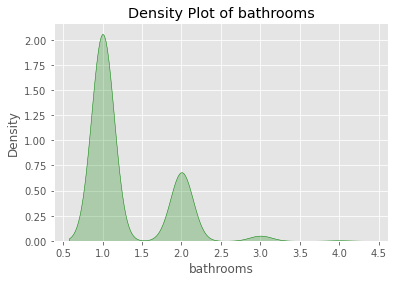

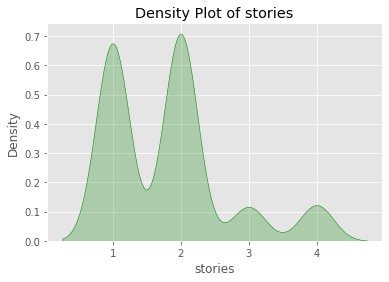

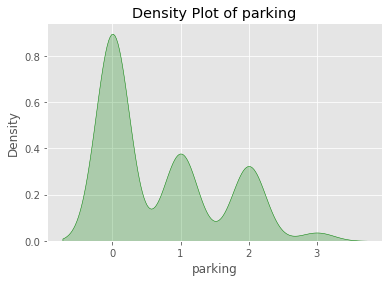

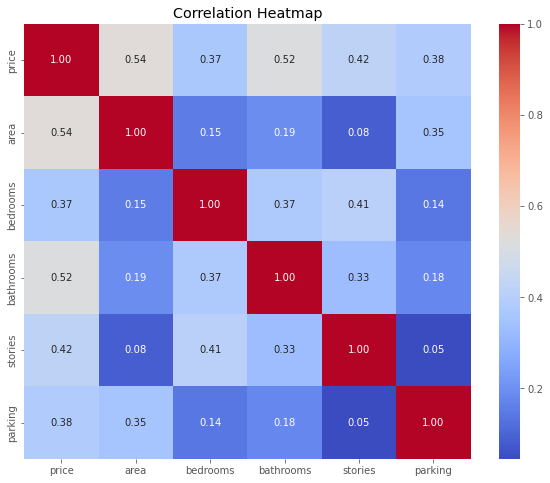

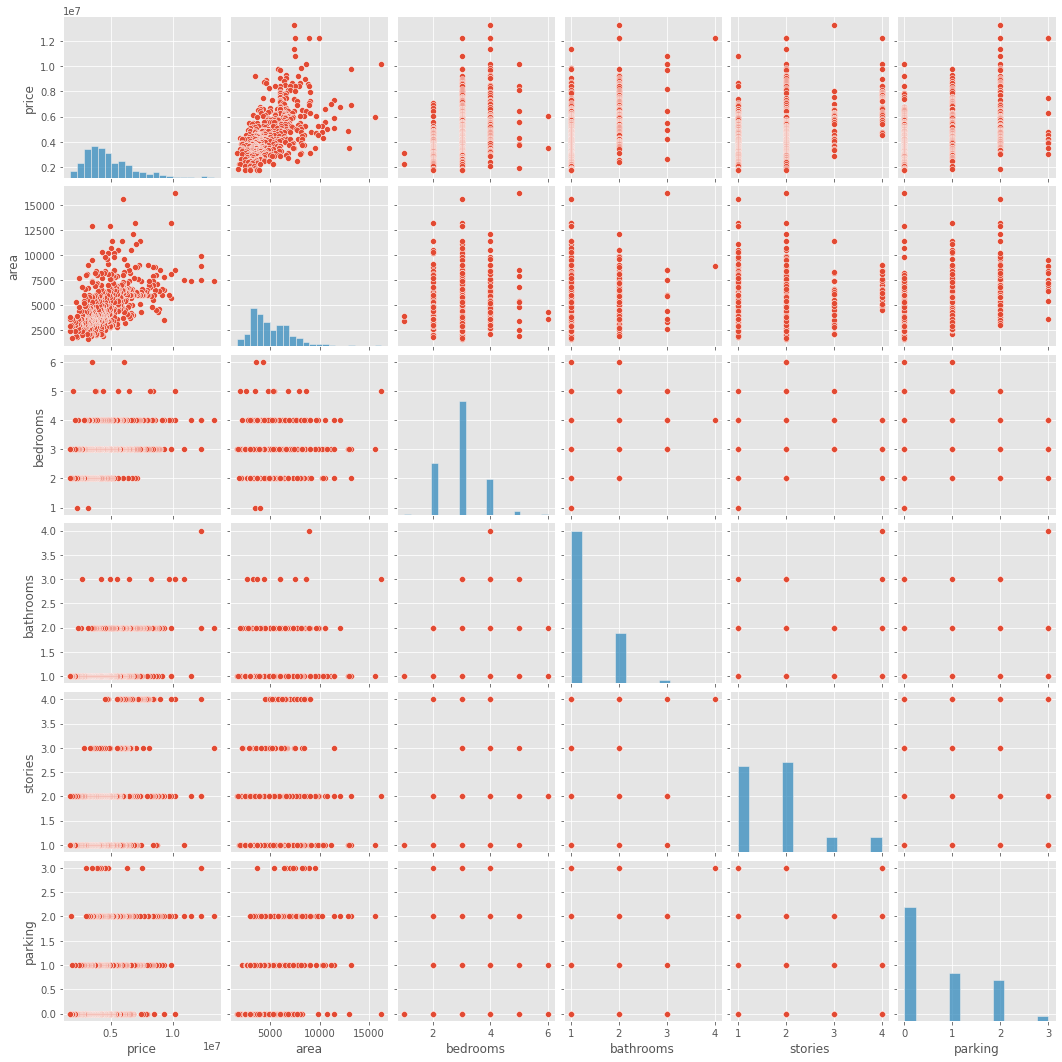

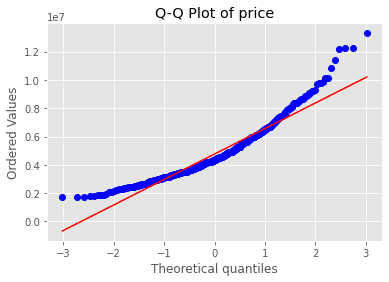

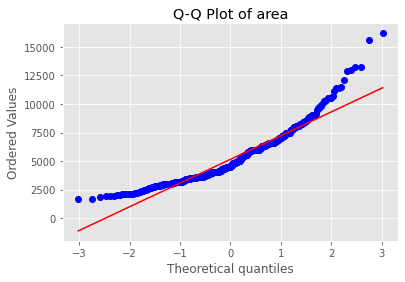

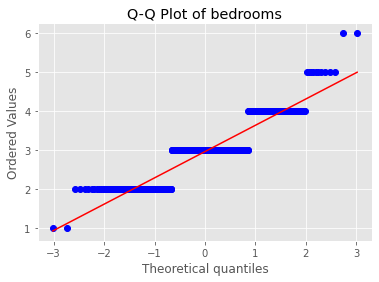

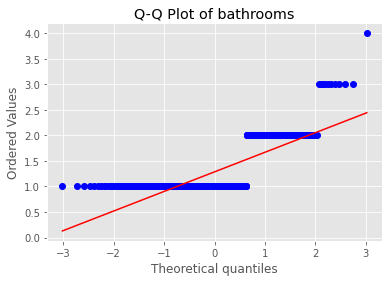

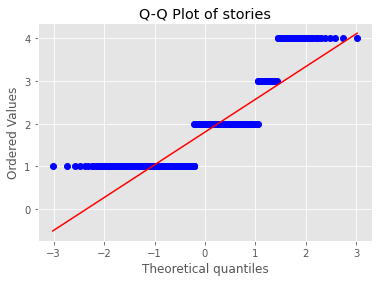

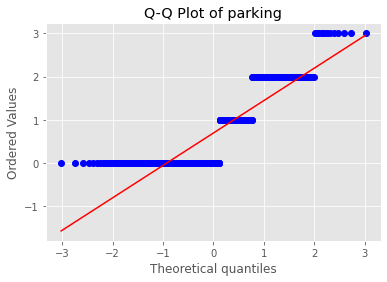


Analysis Completed Successfully!


In [1]:
# Install packages (Run once in Jupyter/Colab)
!pip install pandas numpy scipy matplotlib seaborn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import trim_mean, median_abs_deviation
from scipy.stats import probplot

# Plot style
plt.style.use('ggplot')

# Load dataset
df = pd.read_csv("Housing.csv")

# Display first 5 rows
print("First 5 Rows:")
print(df.head())

# Select only numerical columns
num_df = df.select_dtypes(include=np.number)

print("\nNumerical Columns:")
print(num_df.columns)

# -------------------------------
# DESCRIPTIVE STATISTICS
# -------------------------------
print("\n========== DESCRIPTIVE STATISTICS ==========\n")

for col in num_df.columns:
    data = num_df[col].dropna()

    print(f"\n----- {col} -----")

    # Mean
    mean = data.mean()
    print("Mean:", mean)

    # Median
    median = data.median()
    print("Median:", median)

    # Trimmed Mean (10%)
    tmean = trim_mean(data, 0.10)
    print("Trimmed Mean:", tmean)

    # Weighted Mean
    weights = np.arange(1, len(data)+1)
    wmean = np.average(data, weights=weights)
    print("Weighted Mean:", wmean)

    # Range
    data_range = data.max() - data.min()
    print("Range:", data_range)

    # Variance
    variance = data.var()
    print("Variance:", variance)

    # Standard Deviation
    std = data.std()
    print("Standard Deviation:", std)

    # IQR
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    print("IQR:", IQR)

    # Median Absolute Deviation
    mad = median_abs_deviation(data)
    print("Median Absolute Deviation:", mad)

# -------------------------------
# VISUALIZATIONS
# -------------------------------

# 1. Boxplots
for col in num_df.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=num_df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.show()

# 2. Histogram
for col in num_df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(num_df[col], bins=20, kde=False, color='steelblue')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# 3. Density Plot
for col in num_df.columns:
    plt.figure(figsize=(6,4))
    sns.kdeplot(num_df[col], fill=True, color='green')
    plt.title(f'Density Plot of {col}')
    plt.show()

# 4. Heatmap (Correlation Matrix)
plt.figure(figsize=(10,8))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

# 5. Scatter Plot
if len(num_df.columns) >= 2:
    sns.pairplot(num_df)
    plt.show()

# 6. Q-Q Plot (Normality Check)
for col in num_df.columns:
    plt.figure(figsize=(6,4))
    probplot(num_df[col].dropna(), dist="norm", plot=plt)
    plt.title(f'Q-Q Plot of {col}')
    plt.show()

print("\nAnalysis Completed Successfully!")